# PCB Defect Inspection: Template Matching Baseline

This notebook evaluates **Template Matching** for bare PCB defect inspection.

### Techniques Demonstrated:
1. **Baseline Global Template Matching (`run_template_matching`)**: Structural differencing on preprocessed reference/defective pairs with morphological noise reduction and bounding-box localisation.
2. **Localized Block/Patch Template Matching (`match_template_blockwise`)**: Normalized Cross-Correlation (NCC) over local patches to detect subtle structural defects.

In [9]:
import sys
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from algorithms.common import load_image, preprocess_pair
from algorithms.template_matching import (
    draw_defect_boxes,
    match_template_blockwise,
    run_template_matching,
)

DATASET_ROOT = PROJECT_ROOT / "data" / "raw" / "PCB_DATASET"
IMAGE_ROOT = DATASET_ROOT / "Images"
ANNOTATION_ROOT = DATASET_ROOT / "Annotations"
TEMPLATE_ROOT = DATASET_ROOT / "PCB_USED"

print("Template Matching Environment Ready!")

Template Matching Environment Ready!


## 1. Single Image Demonstration — Missing Hole Defect
We test `01_missing_hole_01.jpg` against reference template `01.JPG`.

Processing Time: 5.562 ms
Detected Defect Regions: 3


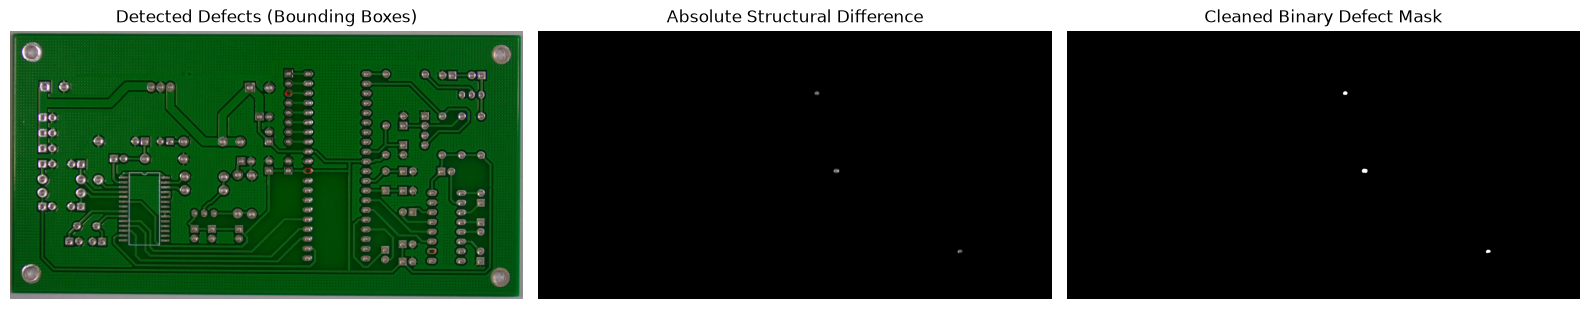

In [10]:
defective_path = IMAGE_ROOT / "Missing_hole" / "01_missing_hole_01.jpg"
reference_path = TEMPLATE_ROOT / "01.JPG"

reference = load_image(reference_path)
defective = load_image(defective_path)

# Shared baseline preprocessing (grayscale + resize + blur)
reference_gray, defective_gray, _ = preprocess_pair(reference, defective)

# 1. Run Baseline Template Matching
diff_map, defect_mask, bounding_boxes, processing_time_ms = run_template_matching(
    reference_gray,
    defective_gray,
    threshold=40.0,
    min_contour_area=20,
)

print(f"Processing Time: {processing_time_ms:.3f} ms")
print(f"Detected Defect Regions: {len(bounding_boxes)}")

# Draw defect bounding boxes on original defective image
annotated_defective = draw_defect_boxes(defective, bounding_boxes)

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(annotated_defective, cv2.COLOR_BGR2RGB))
plt.title("Detected Defects (Bounding Boxes)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(diff_map, cmap="gray")
plt.title("Absolute Structural Difference")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(defect_mask, cmap="gray")
plt.title("Cleaned Binary Defect Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

## 2. Block/Patch-based Template Matching (Normalized Cross-Correlation)
We evaluate local similarity across `64x64` sliding patches.

Blockwise NCC Processing Time: 173.551 ms
Flagged Blocks: 8


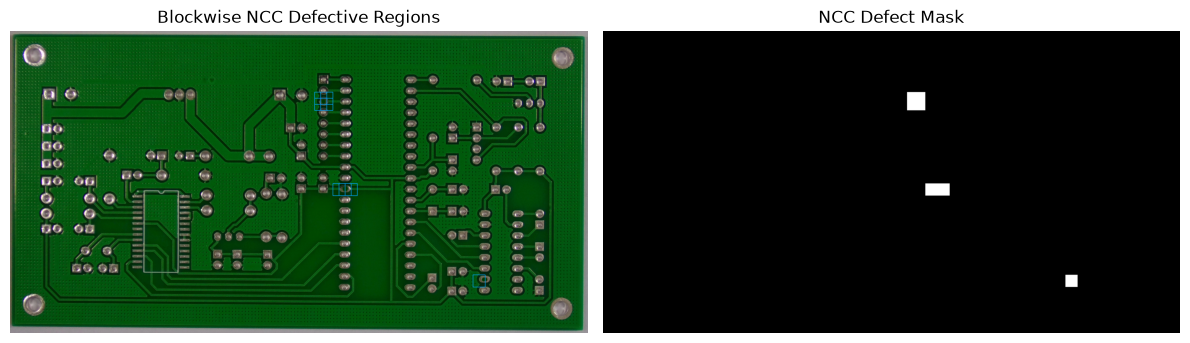

In [11]:
ncc_mask, ncc_boxes, ncc_time_ms = match_template_blockwise(
    reference_gray,
    defective_gray,
    block_size=(64, 64),
    step_size=32,
    corr_threshold=0.68,
)

print(f"Blockwise NCC Processing Time: {ncc_time_ms:.3f} ms")
print(f"Flagged Blocks: {len(ncc_boxes)}")

annotated_ncc = draw_defect_boxes(defective, ncc_boxes, color=(255, 165, 0), thickness=2)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(annotated_ncc, cv2.COLOR_BGR2RGB))
plt.title("Blockwise NCC Defective Regions")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(ncc_mask, cmap="gray")
plt.title("NCC Defect Mask")
plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Multi-Defect Category Comparison
We evaluate one sample from each of the 6 defect categories.

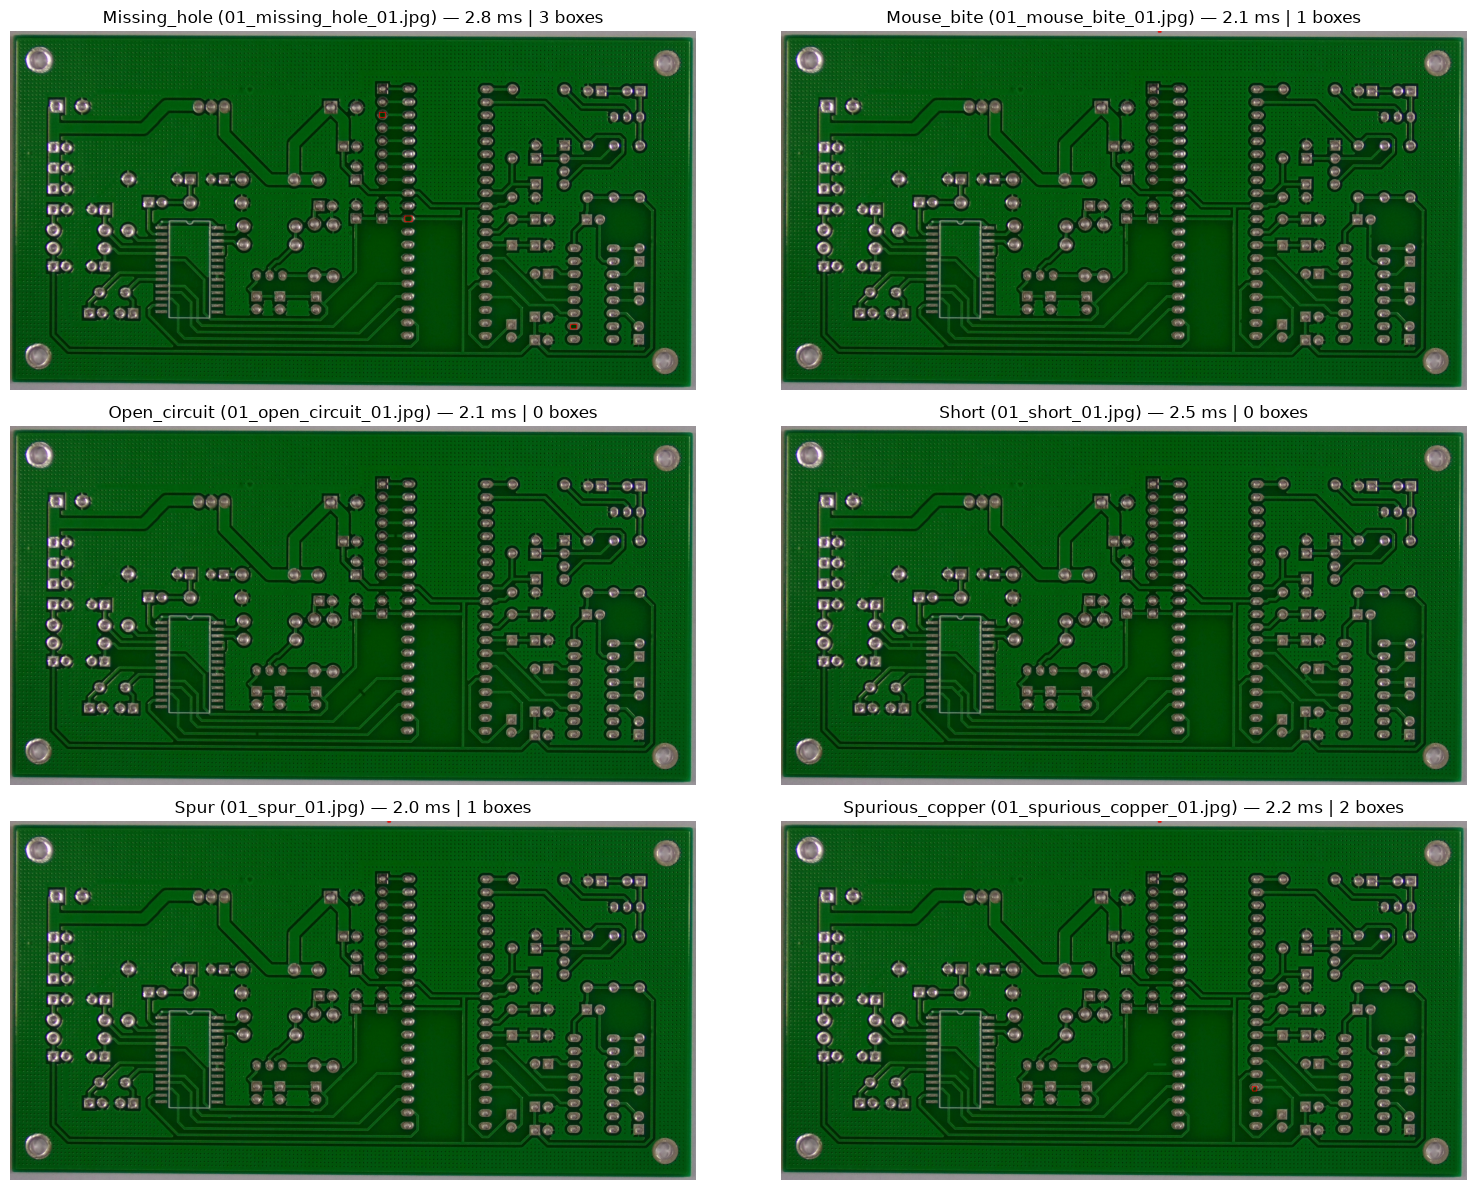

In [12]:
sample_defects = [
    ("Missing_hole", "01_missing_hole_01.jpg", "01.JPG"),
    ("Mouse_bite", "01_mouse_bite_01.jpg", "01.JPG"),
    ("Open_circuit", "01_open_circuit_01.jpg", "01.JPG"),
    ("Short", "01_short_01.jpg", "01.JPG"),
    ("Spur", "01_spur_01.jpg", "01.JPG"),
    ("Spurious_copper", "01_spurious_copper_01.jpg", "01.JPG"),
]

plt.figure(figsize=(16, 12))

for i, (category, img_name, tpl_name) in enumerate(sample_defects, 1):
    def_path = IMAGE_ROOT / category / img_name
    ref_path = TEMPLATE_ROOT / tpl_name
    
    ref_img = load_image(ref_path)
    def_img = load_image(def_path)
    
    ref_g, def_g, _ = preprocess_pair(ref_img, def_img)
    _, mask, boxes, t_ms = run_template_matching(ref_g, def_g, threshold=40.0)
    
    annotated = draw_defect_boxes(def_img, boxes)
    
    plt.subplot(3, 2, i)
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(f"{category} ({img_name}) — {t_ms:.1f} ms | {len(boxes)} boxes")
    plt.axis("off")

plt.tight_layout()
plt.show()